#🛠️ Preparación de los Datos


##Extracción

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv('/content/datos_tratados.csv')
df.head()

,CustomerID,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesDaily,ChargesMonthly,ChargesTotal
0,0002-ORFBO,No,Female,No,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,2.19,65.6,593.30
1,0003-MKNFE,No,Male,No,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,2.00,59.9,542.40
2,0004-TLHLJ,Yes,Male,No,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,2.46,73.9,280.85
3,0011-IGKFF,Yes,Male,Yes,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,3.27,98.0,1237.85
4,0013-EXCHZ,Yes,Female,Yes,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,2.80,83.9,267.40


In [6]:
df.columns

Index(['CustomerID', 'Churn', 'Gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'Tenure', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'ChargesDaily', 'ChargesMonthly',
       'ChargesTotal'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        7043 non-null   object 
 1   Churn             7043 non-null   object 
 2   Gender            7043 non-null   object 
 3   SeniorCitizen     7043 non-null   object 
 4   Partner           7043 non-null   object 
 5   Dependents        7043 non-null   object 
 6   Tenure            7043 non-null   int64  
 7   PhoneService      7043 non-null   object 
 8   MultipleLines     7043 non-null   object 
 9   InternetService   7043 non-null   object 
 10  OnlineSecurity    7043 non-null   object 
 11  OnlineBackup      7043 non-null   object 
 12  DeviceProtection  7043 non-null   object 
 13  TechSupport       7043 non-null   object 
 14  StreamingTV       7043 non-null   object 
 15  StreamingMovies   7043 non-null   object 
 16  Contract          7043 non-null   object 


## Eliminación de Columnas Irrelevantes

In [8]:
df = df.drop(columns=['CustomerID'])
df

,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesDaily,ChargesMonthly,ChargesTotal
0,No,Female,No,Yes,Yes,9,Yes,No,DSL,No,...,No,Yes,Yes,No,One year,Yes,Mailed check,2.19,65.60,593.30
1,No,Male,No,No,No,9,Yes,Yes,DSL,No,...,No,No,No,Yes,Month-to-month,No,Mailed check,2.00,59.90,542.40
2,Yes,Male,No,No,No,4,Yes,No,Fiber optic,No,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,2.46,73.90,280.85
3,Yes,Male,Yes,Yes,No,13,Yes,No,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,3.27,98.00,1237.85
4,Yes,Female,Yes,Yes,No,3,Yes,No,Fiber optic,No,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,2.80,83.90,267.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,No,Female,No,No,No,13,Yes,No,DSL,Yes,...,No,Yes,No,No,One year,No,Mailed check,1.84,55.15,742.90
7039,Yes,Male,No,Yes,No,22,Yes,Yes,Fiber optic,No,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,2.84,85.10,1873.70
7040,No,Male,No,No,No,2,Yes,No,DSL,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,1.68,50.30,92.75
7041,No,Male,No,Yes,Yes,67,Yes,No,DSL,Yes,...,Yes,Yes,No,Yes,Two year,No,Mailed check,2.26,67.85,4627.65


##Encoding

In [9]:
# -------------------------------------------
# 1. Codificar variable objetivo (Churn)
# -------------------------------------------
df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})

# -------------------------------------------
# 2. Label Encoding para variables binarias
# -------------------------------------------
binary_cols = [
    'Gender', 'SeniorCitizen', 'Partner', 'Dependents',
    'PhoneService', 'MultipleLines', 'OnlineSecurity',
    'OnlineBackup', 'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies', 'PaperlessBilling'
]

binary_map = {'Yes': 1, 'No': 0, 'Female': 0, 'Male': 1}
df[binary_cols] = df[binary_cols].replace(binary_map)

# -------------------------------------------
# 3. One-Hot Encoding para variables multiclase
# -------------------------------------------
ohe_cols = ['InternetService', 'Contract', 'PaymentMethod']
df = pd.get_dummies(df, columns=ohe_cols, drop_first=False)

# -------------------------------------------
# Verificación
# -------------------------------------------
print(df.shape)
print(df.dtypes)
print(df.head(3))

(7043, 28)
Churn                                        int64
Gender                                       int64
SeniorCitizen                                int64
Partner                                      int64
Dependents                                   int64
Tenure                                       int64
PhoneService                                 int64
MultipleLines                                int64
OnlineSecurity                               int64
OnlineBackup                                 int64
DeviceProtection                             int64
TechSupport                                  int64
StreamingTV                                  int64
StreamingMovies                              int64
PaperlessBilling                             int64
ChargesDaily                               float64
ChargesMonthly                             float64
ChargesTotal                               float64
InternetService_DSL                           bool
InternetService_Fibe

/tmp/ipykernel_386/288056089.py:17: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[binary_cols] = df[binary_cols].replace(binary_map)


## Verificación de la Proporción de Cancelación (Churn)

=== Distribución de Churn ===
Clientes activos  (0): 5,174  (73.5%)
Clientes cancelados (1): 1,869  (26.5%)

Ratio desbalance: 2.77:1


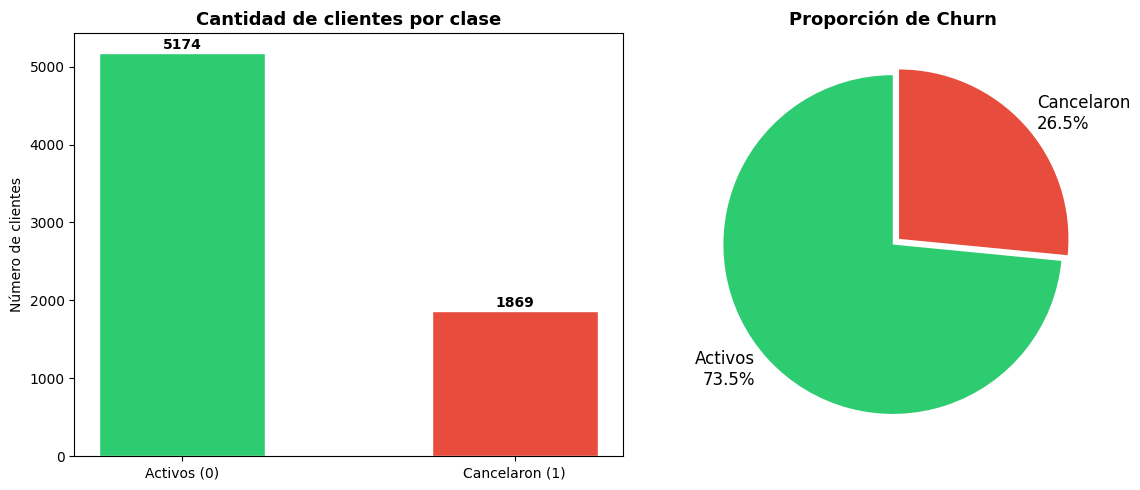

In [10]:

# 1. Proporción de Churn

churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

print("=== Distribución de Churn ===")
print(f"Clientes activos  (0): {churn_counts[0]:,}  ({churn_pct[0]:.1f}%)")
print(f"Clientes cancelados (1): {churn_counts[1]:,}  ({churn_pct[1]:.1f}%)")
print(f"\nRatio desbalance: {churn_counts[0]/churn_counts[1]:.2f}:1")

# -------------------------------------------
# 2. Visualización
# -------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico de barras
axes[0].bar(['Activos (0)', 'Cancelaron (1)'],
            churn_counts.values,
            color=['#2ecc71', '#e74c3c'],
            edgecolor='white', width=0.5)
axes[0].set_title('Cantidad de clientes por clase', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Número de clientes')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Gráfico de torta
axes[1].pie(churn_counts.values,
            labels=[f'Activos\n{churn_pct[0]:.1f}%', f'Cancelaron\n{churn_pct[1]:.1f}%'],
            colors=['#2ecc71', '#e74c3c'],
            explode=(0, 0.05),
            startangle=90,
            textprops={'fontsize': 12})
axes[1].set_title('Proporción de Churn', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('churn_distribucion.png', dpi=150, bbox_inches='tight')
plt.show()

#🎯 Correlación y Selección de Variables

##Análisis de Correlación

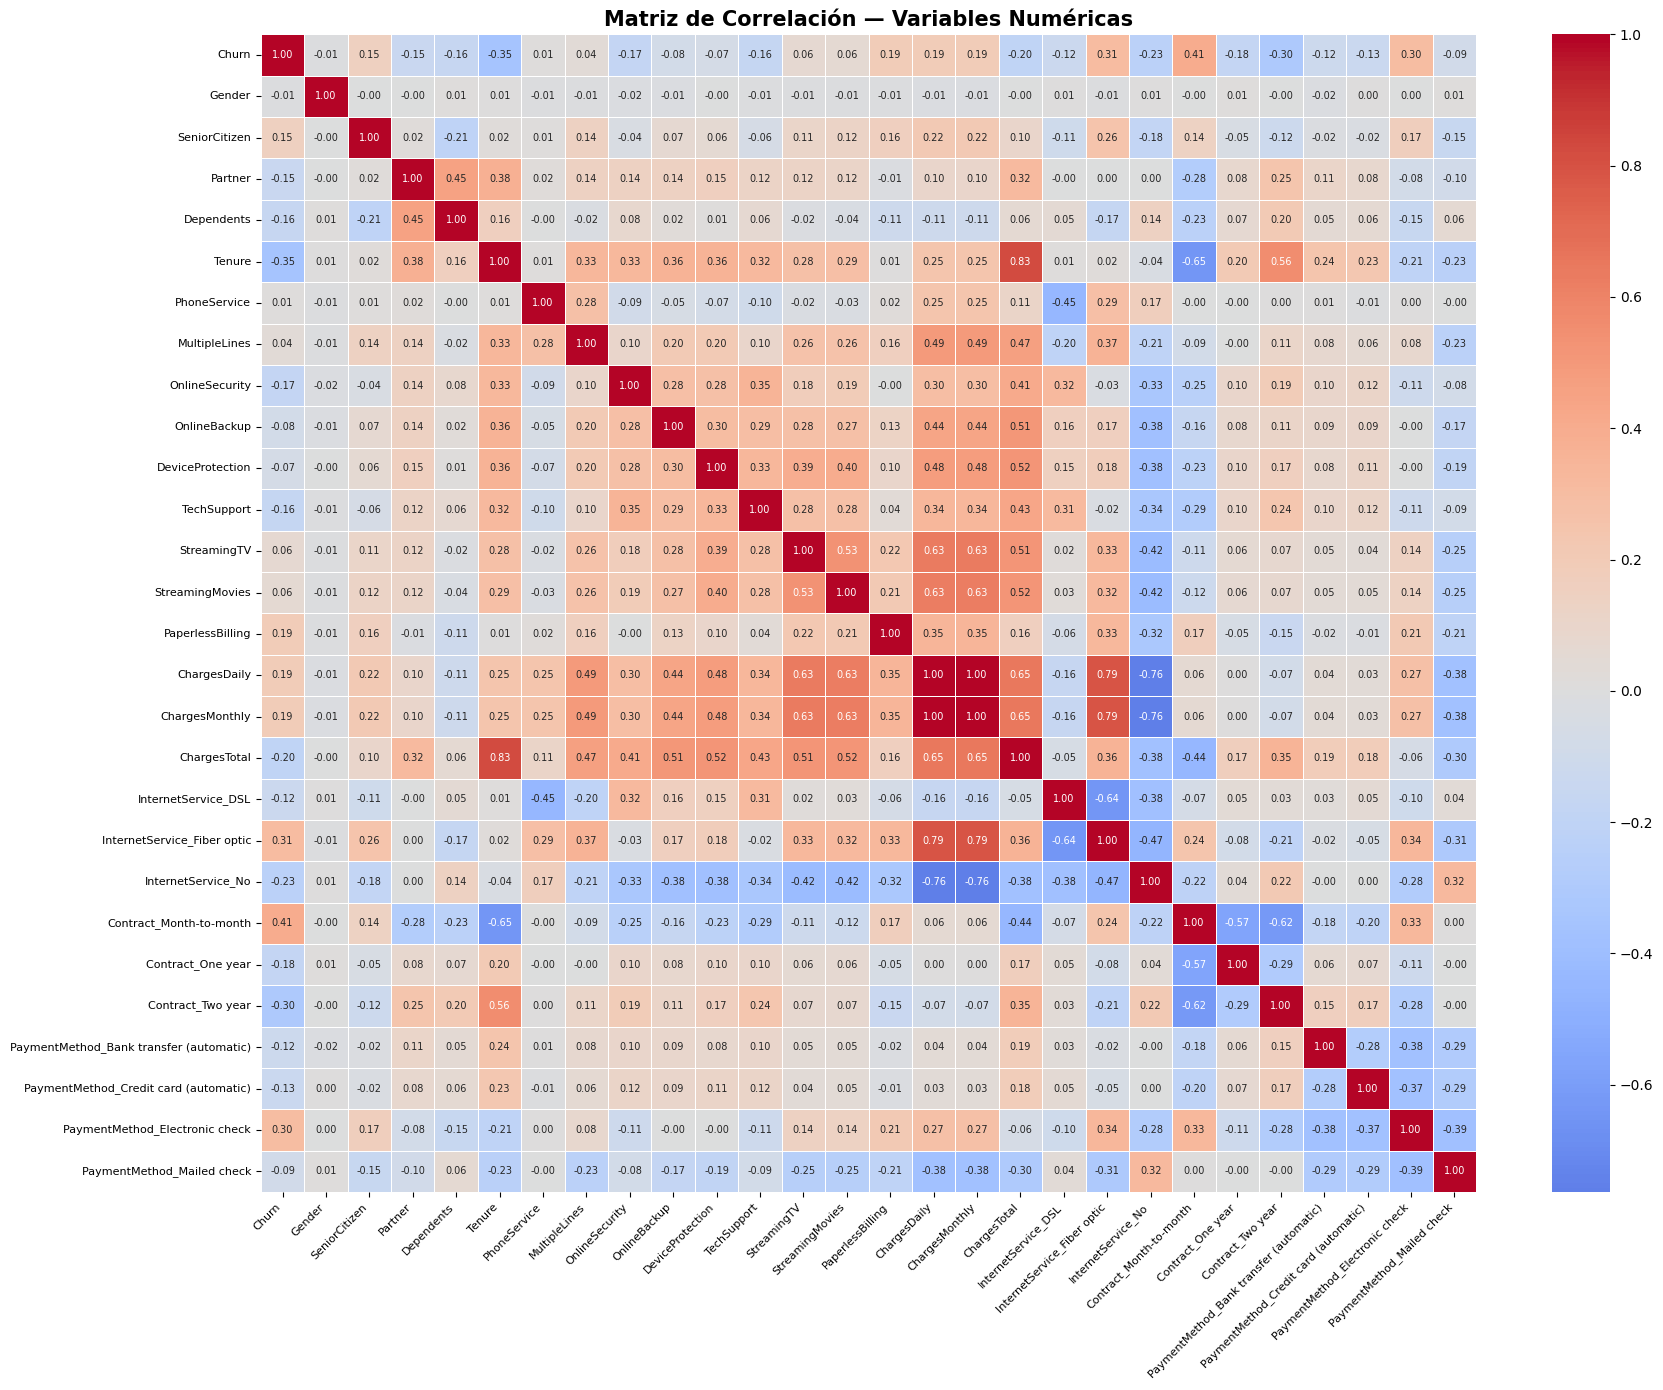

=== Correlación con Churn (ordenado por magnitud) ===

Contract_Month-to-month                       +0.4051  (🔴 positiva)
Tenure                                        -0.3522  (🟢 negativa)
InternetService_Fiber optic                   +0.3080  (🔴 positiva)
Contract_Two year                             -0.3023  (🟢 negativa)
PaymentMethod_Electronic check                +0.3019  (🔴 positiva)
InternetService_No                            -0.2279  (🟢 negativa)
ChargesTotal                                  -0.1983  (🟢 negativa)
ChargesDaily                                  +0.1934  (🔴 positiva)
ChargesMonthly                                +0.1934  (🔴 positiva)
PaperlessBilling                              +0.1918  (🔴 positiva)
Contract_One year                             -0.1778  (🟢 negativa)
OnlineSecurity                                -0.1712  (🟢 negativa)
TechSupport                                   -0.1647  (🟢 negativa)
Dependents                                    -0.1642  (🟢 neg

In [11]:
# -------------------------------------------
# 1. Matriz de correlación
# -------------------------------------------
corr_matrix = df.corr(numeric_only=True)

# -------------------------------------------
# 2. Heatmap completo
# -------------------------------------------
plt.figure(figsize=(18, 14))
sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            linewidths=0.5,
            annot_kws={'size': 7})
plt.title('Matriz de Correlación — Variables Numéricas', fontsize=15, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig('matriz_correlacion.png', dpi=150, bbox_inches='tight')
plt.show()

# -------------------------------------------
# 3. Correlación específica con Churn (ranking)
# -------------------------------------------
churn_corr = corr_matrix['Churn'].drop('Churn').sort_values(key=abs, ascending=False)

print("=== Correlación con Churn (ordenado por magnitud) ===\n")
for var, val in churn_corr.items():
    direccion = '🔴 positiva' if val > 0 else '🟢 negativa'
    print(f"{var:<45} {val:+.4f}  ({direccion})")

##Análisis Dirigido

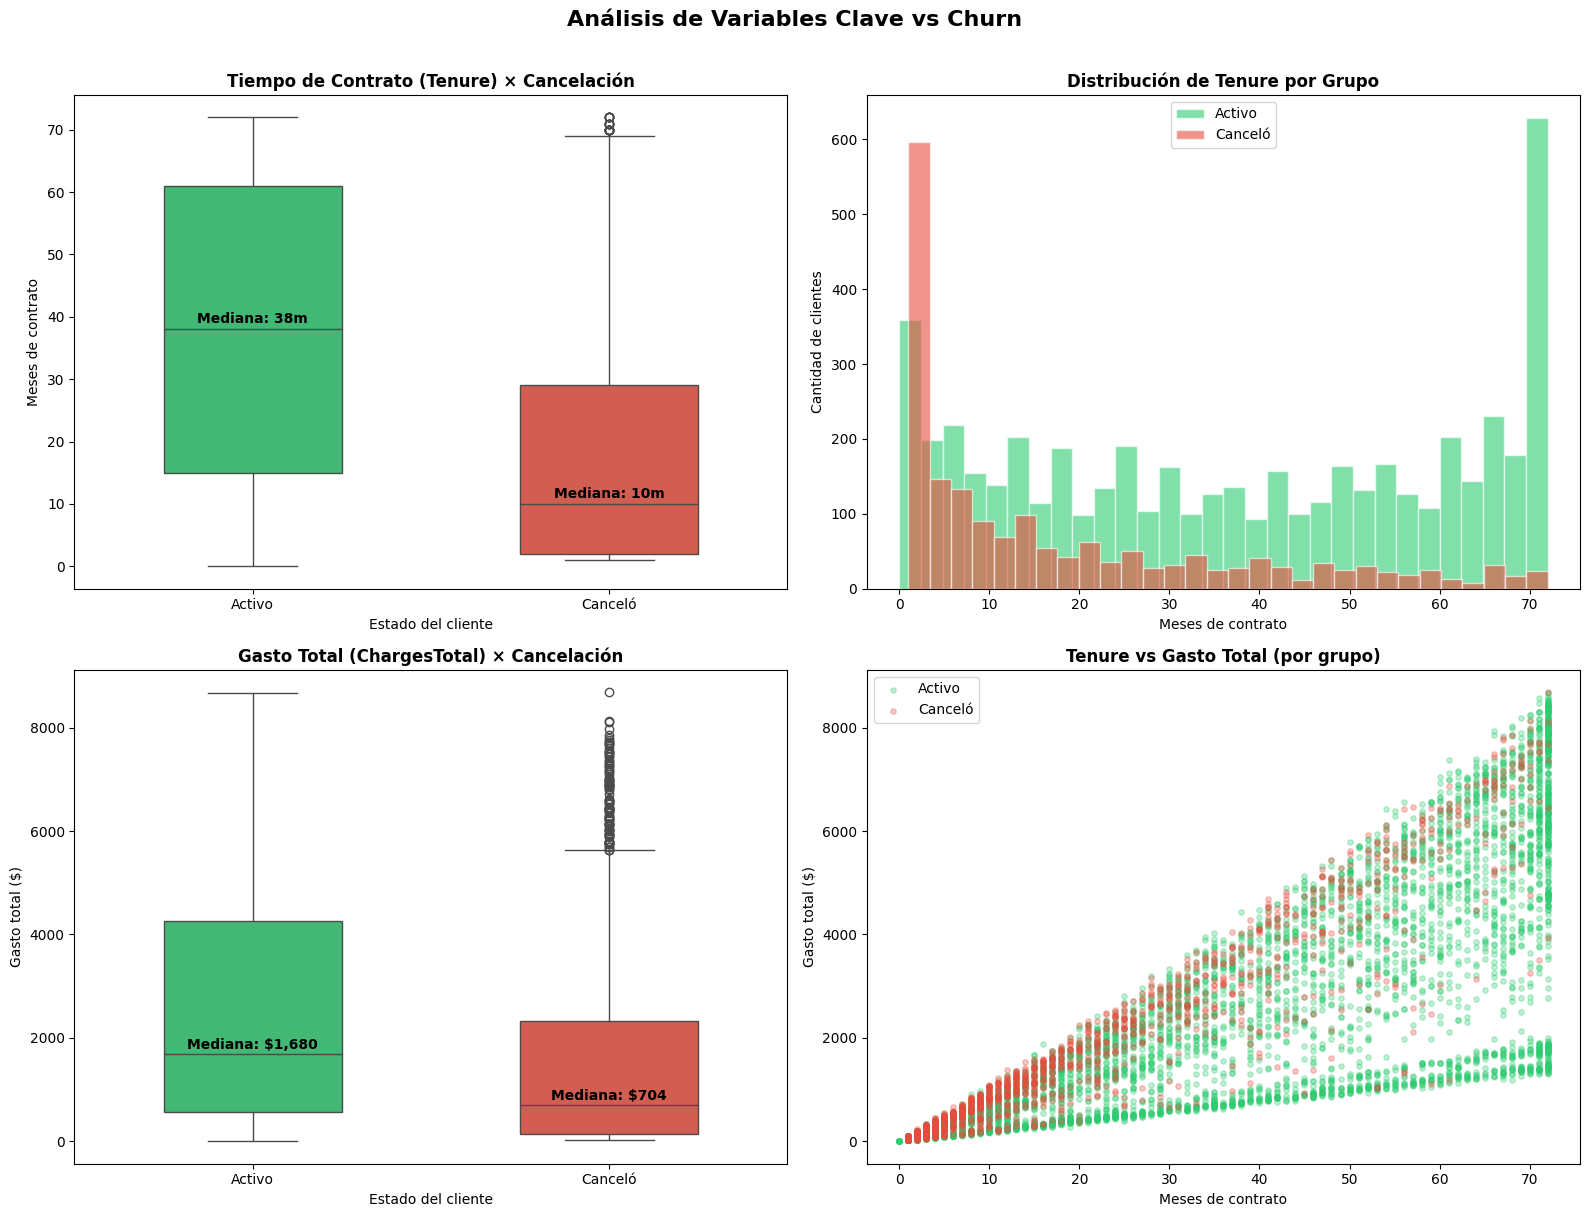

=== Tenure por grupo ===
              count  mean   std  min   25%   50%   75%   max
Churn_Label                                                 
Activo       5174.0  37.6  24.1  0.0  15.0  38.0  61.0  72.0
Canceló      1869.0  18.0  19.5  1.0   2.0  10.0  29.0  72.0

=== ChargesTotal por grupo ===
              count    mean     std   min    25%     50%     75%     max
Churn_Label                                                             
Activo       5174.0  2549.9  2330.0   0.0  572.9  1679.5  4262.8  8672.4
Canceló      1869.0  1531.8  1890.8  18.8  134.5   703.6  2331.3  8684.8


In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Análisis de Variables Clave vs Churn', fontsize=16, fontweight='bold', y=1.01)

churn_labels = {0: 'Activo', 1: 'Canceló'}
colors = {'Activo': '#2ecc71', 'Canceló': '#e74c3c'}
df['Churn_Label'] = df['Churn'].map(churn_labels)

# -------------------------------------------
# 1. Boxplot: Tenure vs Churn
# -------------------------------------------
sns.boxplot(data=df, x='Churn_Label', y='Tenure',
            hue='Churn_Label', palette=colors,
            legend=False, ax=axes[0, 0], width=0.5)
axes[0, 0].set_title('Tiempo de Contrato (Tenure) × Cancelación', fontweight='bold')
axes[0, 0].set_xlabel('Estado del cliente')
axes[0, 0].set_ylabel('Meses de contrato')

medians = df.groupby('Churn_Label')['Tenure'].median()
for i, (label, median) in enumerate(medians.items()):
    axes[0, 0].text(i, median + 1, f'Mediana: {median:.0f}m',
                    ha='center', fontsize=10, fontweight='bold')

# -------------------------------------------
# 2. Histograma: Tenure por grupo Churn
# -------------------------------------------
for churn_val, label in churn_labels.items():
    subset = df[df['Churn'] == churn_val]['Tenure']
    axes[0, 1].hist(subset, bins=30, alpha=0.6,
                    label=label, color=colors[label], edgecolor='white')
axes[0, 1].set_title('Distribución de Tenure por Grupo', fontweight='bold')
axes[0, 1].set_xlabel('Meses de contrato')
axes[0, 1].set_ylabel('Cantidad de clientes')
axes[0, 1].legend()

# -------------------------------------------
# 3. Boxplot: ChargesTotal vs Churn
# -------------------------------------------
sns.boxplot(data=df, x='Churn_Label', y='ChargesTotal',
            hue='Churn_Label', palette=colors,
            legend=False, ax=axes[1, 0], width=0.5)
axes[1, 0].set_title('Gasto Total (ChargesTotal) × Cancelación', fontweight='bold')
axes[1, 0].set_xlabel('Estado del cliente')
axes[1, 0].set_ylabel('Gasto total ($)')

medians_charges = df.groupby('Churn_Label')['ChargesTotal'].median()
for i, (label, median) in enumerate(medians_charges.items()):
    axes[1, 0].text(i, median + 100, f'Mediana: ${median:,.0f}',
                    ha='center', fontsize=10, fontweight='bold')

# -------------------------------------------
# 4. Scatter: Tenure vs ChargesTotal coloreado por Churn
# -------------------------------------------
for churn_val, label in churn_labels.items():
    subset = df[df['Churn'] == churn_val]
    axes[1, 1].scatter(subset['Tenure'], subset['ChargesTotal'],
                       alpha=0.3, s=15, label=label, color=colors[label])
axes[1, 1].set_title('Tenure vs Gasto Total (por grupo)', fontweight='bold')
axes[1, 1].set_xlabel('Meses de contrato')
axes[1, 1].set_ylabel('Gasto total ($)')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('analisis_variables_churn.png', dpi=150, bbox_inches='tight')
plt.show()

# -------------------------------------------
# 5. Estadísticas descriptivas por grupo
# -------------------------------------------
print("=== Tenure por grupo ===")
print(df.groupby('Churn_Label')['Tenure'].describe().round(1))
print("\n=== ChargesTotal por grupo ===")
print(df.groupby('Churn_Label')['ChargesTotal'].describe().round(1))

# Limpiar columna auxiliar
df.drop(columns=['Churn_Label'], inplace=True)

#🤖 Modelado Predictivo

##Separación de Datos

In [13]:
from sklearn.model_selection import train_test_split

# -------------------------------------------
# 1. Separar variable objetivo y features
# -------------------------------------------
X = df.drop(columns=['Churn'])
y = df['Churn']

# -------------------------------------------
# 2. División 80/20 con stratify
# -------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y        # Mantiene la proporción de churn en ambos conjuntos
)

# -------------------------------------------
# 3. Verificación
# -------------------------------------------
print(f"Total registros:      {len(df):,}")
print(f"Entrenamiento (80%):  {len(X_train):,}")
print(f"Prueba (20%):         {len(X_test):,}")

print(f"\n=== Proporción de Churn ===")
print(f"Train — Churn: {y_train.mean()*100:.1f}%  |  No Churn: {(1-y_train.mean())*100:.1f}%")
print(f"Test  — Churn: {y_test.mean()*100:.1f}%  |  No Churn: {(1-y_test.mean())*100:.1f}%")

Total registros:      7,043
Entrenamiento (80%):  5,634
Prueba (20%):         1,409

=== Proporción de Churn ===
Train — Churn: 26.5%  |  No Churn: 73.5%
Test  — Churn: 26.5%  |  No Churn: 73.5%


##Creación de Modelos

### Decision Tree

       DECISION TREE — Resultados
              precision    recall  f1-score   support

  Activo (0)       0.81      0.83      0.82      1035
 Canceló (1)       0.49      0.46      0.48       374

    accuracy                           0.73      1409
   macro avg       0.65      0.64      0.65      1409
weighted avg       0.72      0.73      0.73      1409

ROC-AUC Score: 0.6450


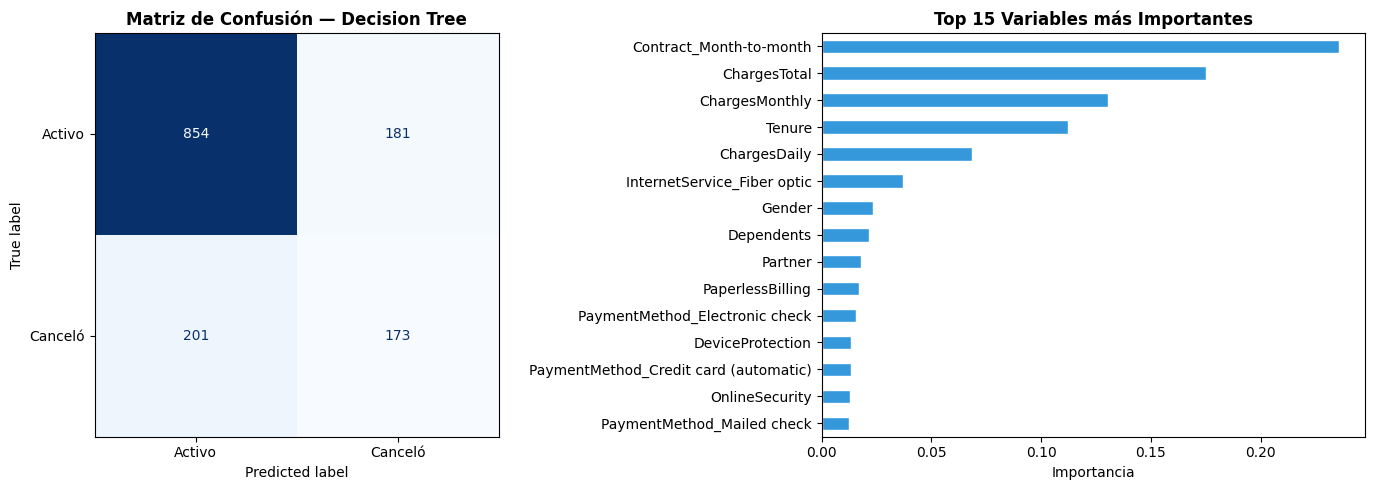

In [14]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt

# -------------------------------------------
# 1. Entrenar modelo
# -------------------------------------------
dt_model = DecisionTreeClassifier(
    random_state=42,
    class_weight='balanced'   # Maneja el desbalance que identificamos
)
dt_model.fit(X_train, y_train)

# -------------------------------------------
# 2. Predicciones
# -------------------------------------------
y_pred_dt = dt_model.predict(X_test)
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]

# -------------------------------------------
# 3. Métricas
# -------------------------------------------
print("=" * 50)
print("       DECISION TREE — Resultados")
print("=" * 50)
print(classification_report(y_test, y_pred_dt,
      target_names=['Activo (0)', 'Canceló (1)']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_dt):.4f}")

# -------------------------------------------
# 4. Matriz de confusión
# -------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_dt,
    display_labels=['Activo', 'Canceló'],
    colorbar=False, cmap='Blues', ax=axes[0])
axes[0].set_title('Matriz de Confusión — Decision Tree',
                  fontweight='bold')

# -------------------------------------------
# 5. Importancia de variables (Top 15)
# -------------------------------------------
importances = pd.Series(dt_model.feature_importances_,
                        index=X.columns).sort_values(ascending=True).tail(15)
importances.plot(kind='barh', ax=axes[1],
                 color='#3498db', edgecolor='white')
axes[1].set_title('Top 15 Variables más Importantes',
                  fontweight='bold')
axes[1].set_xlabel('Importancia')

plt.tight_layout()
plt.savefig('decision_tree_resultados.png', dpi=150, bbox_inches='tight')
plt.show()

### Random Forest

       RANDOM FOREST — Resultados
              precision    recall  f1-score   support

  Activo (0)       0.82      0.91      0.86      1035
 Canceló (1)       0.65      0.46      0.54       374

    accuracy                           0.79      1409
   macro avg       0.73      0.68      0.70      1409
weighted avg       0.78      0.79      0.78      1409

ROC-AUC Score: 0.8259


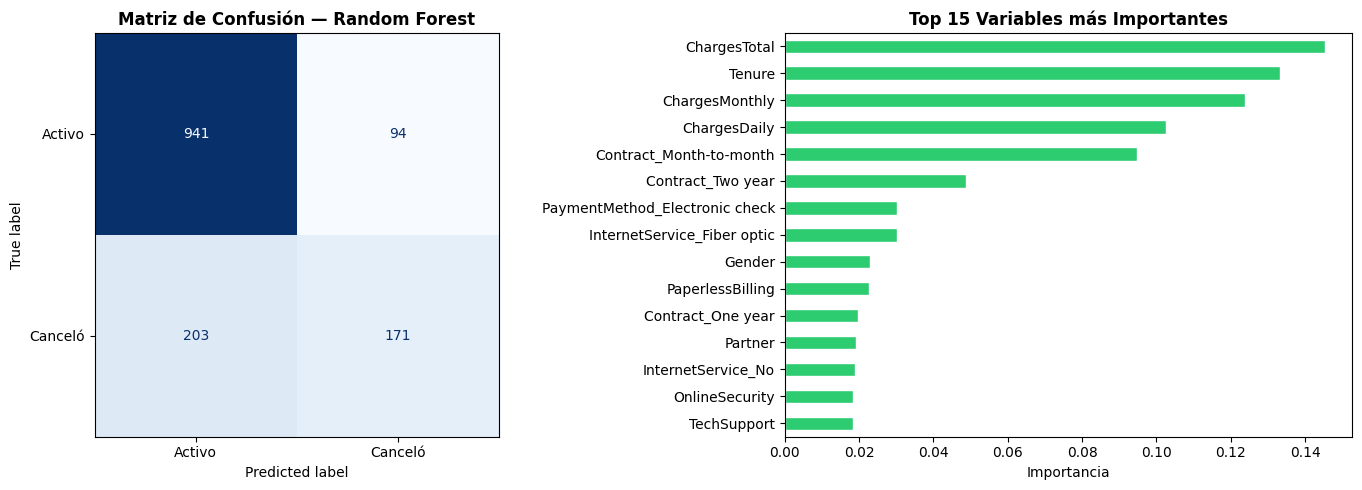

In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt

# -------------------------------------------
# 1. Entrenar modelo
# -------------------------------------------
rf_model = RandomForestClassifier(
    n_estimators=100,       # 100 árboles
    random_state=42,
    class_weight='balanced', # Maneja el desbalance
    n_jobs=-1                # Usa todos los núcleos disponibles
)
rf_model.fit(X_train, y_train)

# -------------------------------------------
# 2. Predicciones
# -------------------------------------------
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# -------------------------------------------
# 3. Métricas
# -------------------------------------------
print("=" * 50)
print("       RANDOM FOREST — Resultados")
print("=" * 50)
print(classification_report(y_test, y_pred_rf,
      target_names=['Activo (0)', 'Canceló (1)']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_rf):.4f}")

# -------------------------------------------
# 4. Matriz de confusión
# -------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf,
    display_labels=['Activo', 'Canceló'],
    colorbar=False, cmap='Blues', ax=axes[0])
axes[0].set_title('Matriz de Confusión — Random Forest',
                  fontweight='bold')

# -------------------------------------------
# 5. Importancia de variables (Top 15)
# -------------------------------------------
importances = pd.Series(rf_model.feature_importances_,
                        index=X.columns).sort_values(ascending=True).tail(15)
importances.plot(kind='barh', ax=axes[1],
                 color='#2ecc71', edgecolor='white')
axes[1].set_title('Top 15 Variables más Importantes',
                  fontweight='bold')
axes[1].set_xlabel('Importancia')

plt.tight_layout()
plt.savefig('random_forest_resultados.png', dpi=150, bbox_inches='tight')
plt.show()

###XGBoost

scale_pos_weight: 2.77
         XGBOOST — Resultados
              precision    recall  f1-score   support

  Activo (0)       0.89      0.75      0.82      1035
 Canceló (1)       0.52      0.76      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.80      0.75      0.76      1409

ROC-AUC Score: 0.8373


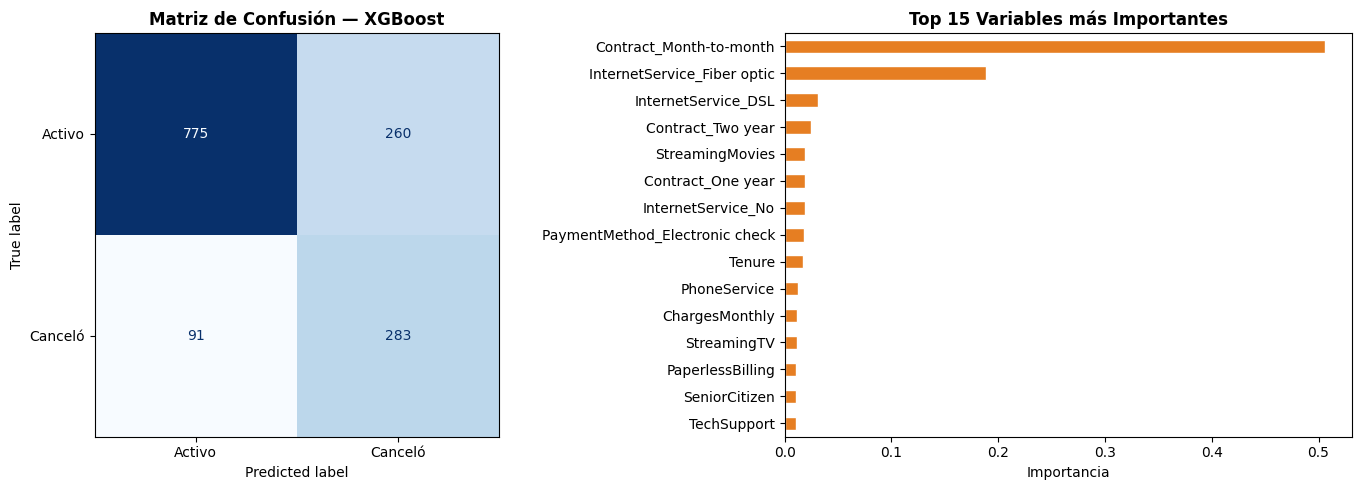

In [16]:
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report,
                             roc_auc_score, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt

# -------------------------------------------
# 1. Calcular scale_pos_weight para desbalance
# -------------------------------------------
scale = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale:.2f}")

# -------------------------------------------
# 2. Entrenar modelo
# -------------------------------------------
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    scale_pos_weight=scale,  # Maneja el desbalance
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)
xgb_model.fit(X_train, y_train)

# -------------------------------------------
# 3. Predicciones
# -------------------------------------------
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

# -------------------------------------------
# 4. Métricas
# -------------------------------------------
print("=" * 50)
print("         XGBOOST — Resultados")
print("=" * 50)
print(classification_report(y_test, y_pred_xgb,
      target_names=['Activo (0)', 'Canceló (1)']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_xgb):.4f}")

# -------------------------------------------
# 5. Matriz de confusión
# -------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_xgb,
    display_labels=['Activo', 'Canceló'],
    colorbar=False, cmap='Blues', ax=axes[0])
axes[0].set_title('Matriz de Confusión — XGBoost',
                  fontweight='bold')

# -------------------------------------------
# 6. Importancia de variables (Top 15)
# -------------------------------------------
importances = pd.Series(xgb_model.feature_importances_,
                        index=X.columns).sort_values(ascending=True).tail(15)
importances.plot(kind='barh', ax=axes[1],
                 color='#e67e22', edgecolor='white')
axes[1].set_title('Top 15 Variables más Importantes',
                  fontweight='bold')
axes[1].set_xlabel('Importancia')

plt.tight_layout()
plt.savefig('xgboost_resultados.png', dpi=150, bbox_inches='tight')
plt.show()

##Evaluación de los Modelos

GBoost es el mejor modelo para este problema de churn. Aunque el Random Forest tiene mejor Precision (0.65 vs 0.52), XGBoost supera en las métricas que realmente importan para retención de clientes: Recall 0.76 vs 0.46, F1-Score 0.62 vs 0.54, y ROC-AUC 0.8373 vs 0.8259. Detectar el 76% de los clientes que van a cancelar es el objetivo central de cualquier modelo de churn.

### XGBoost Optimizado


     XGBOOST AJUSTE FINO — Resultados
              precision    recall  f1-score   support

  Activo (0)       0.91      0.74      0.82      1035
 Canceló (1)       0.53      0.80      0.63       374

    accuracy                           0.76      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.81      0.76      0.77      1409

ROC-AUC Train: 0.8753
ROC-AUC Test:  0.8480
Diferencia:    0.0273  ✅ Sin overfitting

CV ROC-AUC (5 folds): 0.8484 ± 0.0084

    XGBoost Optimizado vs Ajuste Fino
ROC-AUC Optimizado:  0.8442
ROC-AUC Ajuste Fino: 0.8480
Cambio:              +0.0038


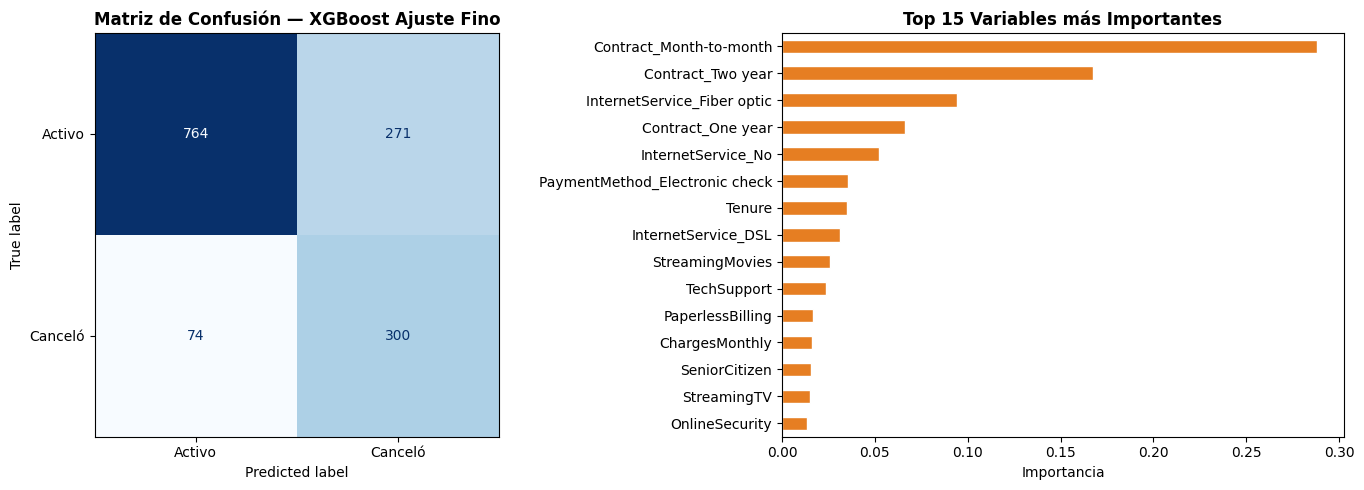

In [20]:
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report,
                             roc_auc_score, ConfusionMatrixDisplay)
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt

# -------------------------------------------
# 1. Entrenar modelo ajuste fino
# -------------------------------------------
xgb_optimized2 = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,             # Reducido de 4 a 3
    subsample=0.7,           # Reducido de 0.8 a 0.7
    colsample_bytree=0.7,    # Reducido de 0.8 a 0.7
    reg_alpha=0.5,           # Aumentado de 0.1 a 0.5
    reg_lambda=2.0,          # Aumentado de 1.0 a 2.0
    scale_pos_weight=scale,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)
xgb_optimized2.fit(X_train, y_train)

# -------------------------------------------
# 2. Predicciones
# -------------------------------------------
y_pred_xgb_opt2 = xgb_optimized2.predict(X_test)
y_prob_xgb_opt2 = xgb_optimized2.predict_proba(X_test)[:, 1]

# -------------------------------------------
# 3. Métricas train vs test
# -------------------------------------------
auc_train = roc_auc_score(y_train, xgb_optimized2.predict_proba(X_train)[:, 1])
auc_test  = roc_auc_score(y_test, y_prob_xgb_opt2)
diff = auc_train - auc_test

print("=" * 55)
print("     XGBOOST AJUSTE FINO — Resultados")
print("=" * 55)
print(classification_report(y_test, y_pred_xgb_opt2,
      target_names=['Activo (0)', 'Canceló (1)']))
print(f"ROC-AUC Train: {auc_train:.4f}")
print(f"ROC-AUC Test:  {auc_test:.4f}")
print(f"Diferencia:    {diff:.4f}  {'✅ Sin overfitting' if diff < 0.05 else '⚠️ Overfitting leve'}")

# -------------------------------------------
# 4. Validación cruzada (5 folds)
# -------------------------------------------
cv_scores = cross_val_score(xgb_optimized2, X_train, y_train,
                             cv=5, scoring='roc_auc', n_jobs=-1)
print(f"\nCV ROC-AUC (5 folds): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# -------------------------------------------
# 5. Comparación vs versión anterior
# -------------------------------------------
print("\n" + "=" * 55)
print("    XGBoost Optimizado vs Ajuste Fino")
print("=" * 55)
print(f"ROC-AUC Optimizado:  0.8442")
print(f"ROC-AUC Ajuste Fino: {auc_test:.4f}")
print(f"Cambio:              {auc_test - 0.8442:+.4f}")

# -------------------------------------------
# 6. Visualización
# -------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_xgb_opt2,
    display_labels=['Activo', 'Canceló'],
    colorbar=False, cmap='Blues', ax=axes[0])
axes[0].set_title('Matriz de Confusión — XGBoost Ajuste Fino',
                  fontweight='bold')

importances = pd.Series(xgb_optimized2.feature_importances_,
                        index=X.columns).sort_values(ascending=True).tail(15)
importances.plot(kind='barh', ax=axes[1],
                 color='#e67e22', edgecolor='white')
axes[1].set_title('Top 15 Variables más Importantes',
                  fontweight='bold')
axes[1].set_xlabel('Importancia')

plt.tight_layout()
plt.savefig('xgboost_ajuste_fino.png', dpi=150, bbox_inches='tight')
plt.show()

#📋 Interpretación y Conclusiones

##Análisis de la Importancia de las Variables

### Dataset
- 7.043 clientes, 22 variables, sin valores nulos
- Tasa de churn: **26.5%** (1.869 clientes cancelaron)
- Desbalance moderado 3:1 → tratado con `scale_pos_weight`


### Modelo Seleccionado: XGBoost Ajuste Fino

| Métrica | Resultado |
|---|---|
| ROC-AUC | 0.848 |
| Recall (Churn) | 0.80 — detecta 8 de cada 10 cancelaciones |
| F1-Score (Churn) | 0.63 |
| Overfitting | No (diferencia Train/Test = 0.027) |


### Comparación de Modelos

| Modelo | Recall | F1 | ROC-AUC | Observación |
|---|---|---|---|---|
| Decision Tree | 0.46 | 0.48 | 0.645 | Underfitting |
| Random Forest | 0.46 | 0.54 | 0.826 | Buena precisión, bajo recall |
| XGBoost Original | 0.76 | 0.62 | 0.837 | Leve overfitting |
| XGBoost Optimizado | 0.78 | 0.63 | 0.844 | Leve overfitting |
| **XGBoost Ajuste Fino** | **0.80** | **0.63** | **0.848** | ✅ Modelo final |

##Conclusiones

### Factores más Influyentes en la Cancelación

1. **Tenure** — A mayor antigüedad, menor probabilidad de churn
2. **Contrato mes a mes** — Mayor tasa de cancelación que contratos anuales
3. **Cargos mensuales altos** — Aumentan el riesgo de churn
4. **Fibra óptica** — Mayor churn que clientes con DSL
5. **Sin soporte técnico** — Ausencia de TechSupport aumenta el churn
6. **Sin seguridad online** — Ausencia de OnlineSecurity aumenta el churn
7. **Pago por cheque electrónico** — Mayor tasa de cancelación vs otros métodos
8. **Adultos mayores** — Mayor propensión al churn


### Estrategias de Retención Recomendadas

- Reforzar onboarding durante los primeros 12 meses (período crítico)
- Incentivar migración de contratos mensuales a anuales o bianuales
- Promover adopción de TechSupport y OnlineSecurity
- Revisar satisfacción en clientes de fibra óptica
- Incentivar cambio de método de pago a débito automático